In [1]:
import pandas as pd

In [3]:
BIT_data = pd.read_csv('bitcoin_tarihsel_ham.csv')
df = BIT_data.copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1838 entries, 0 to 1837
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Tarih   1838 non-null   object
 1   Deger   1838 non-null   object
dtypes: object(2)
memory usage: 28.8+ KB


In [5]:
df.head()

,Tarih,Deger
0,8 Aralık 2020,$18.337
1,9 Aralık 2020,$18.565
2,10 Aralık 2020,$18.262
3,11 Aralık 2020,$18.058
4,12 Aralık 2020,$18.807


In [7]:
aylar = {
    'Ocak': '01', 'Şubat': '02', 'Mart': '03', 'Nisan': '04', 'Mayıs': '05', 'Haziran': '06',
    'Temmuz': '07', 'Ağustos': '08', 'Eylül': '09', 'Ekim': '10', 'Kasım': '11', 'Aralık': '12'
}

# Tarih sütunundaki ay isimlerini değiştirme
for tr, num in aylar.items():
    df['Tarih'] = df['Tarih'].str.replace(tr, num, regex=False)

# 2. Datetime formatına çevirme (Gün Ay Yıl formatında olduğu için dayfirst=True)
# Artık format "15 10 2021" gibi oldu, bunu datetime'a çeviriyoruz.
df['Tarih'] = pd.to_datetime(df['Tarih'], format='%d %m %Y')

# 3. Kronolojik Sıralama (Zaman serisi için çok kritiktir!)
df = df.sort_values('Tarih').reset_index(drop=True)

print(df.info())

ValueError: time data "
              
                Bitcoin
              
            " doesn't match format "%d %m %Y", at position 1828. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [9]:
print(df[df.Tarih == """
              
                Bitcoin
              
            """])

                                                  Tarih    Deger
1828  \n              \n                Bitcoin\n   ...  $90.670


In [11]:
df.loc[1820:1835, :]

,Tarih,Deger
1820,1 12 2025,$85.510
1821,2 12 2025,$90.990
1822,3 12 2025,$92.925
1823,4 12 2025,$92.516
1824,5 12 2025,$89.309
1825,6 12 2025,$89.549
1826,7 12 2025,$91.450
1827,8 12 2025,$90.900
1828,\n \n Bitcoin\n ...,$90.670
1829,\n \n Ethereum\n ...,"$3.128,19"


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1838 entries, 0 to 1837
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Tarih   1838 non-null   object
 1   Deger   1838 non-null   object
dtypes: object(2)
memory usage: 28.8+ KB


In [15]:
df.loc[1828::]

,Tarih,Deger
1828,\n \n Bitcoin\n ...,$90.670
1829,\n \n Ethereum\n ...,"$3.128,19"
1830,\n \n Ripple\n ...,"$2,0857"
1831,\n \n Litecoin\n ...,"$83,66"
1832,\n \n Euro Amerika...,"1,1640"
1833,\n \n Dolar Endeks...,"99,0500"
1834,\n \n Brent Petrol...,"$62,32"
1835,\n \n TR 2 Yıllık ...,"38,09"
1836,\n \n Döviz Sepeti...,"46,0950"
1837,\n \n BIST 100\n ...,"11.189,50"


Anlaşılan veriyi kazırken burada ufak bir hata olmuş ve sekiz aralık sonrasında da bunları kazımış. Zaten ben veriyi de sekiz aralığa kadar çekmiştim. Problem görünmüyor. Bunu kaldırıp devam edicem.

In [17]:
df = df.loc[:1827]
df.tail()

,Tarih,Deger
1823,4 12 2025,$92.516
1824,5 12 2025,$89.309
1825,6 12 2025,$89.549
1826,7 12 2025,$91.450
1827,8 12 2025,$90.900


Tamam artık devam edebiliriz.

In [19]:
df['Tarih'] = pd.to_datetime(df['Tarih'], format='%d %m %Y')

# 3. Kronolojik Sıralama (Zaman serisi için çok kritiktir!)
df = df.sort_values('Tarih').reset_index(drop=True)

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1828 entries, 0 to 1827
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Tarih   1828 non-null   datetime64[ns]
 1   Deger   1828 non-null   object        
dtypes: datetime64[ns](1), object(1)
memory usage: 28.7+ KB
None


In [21]:
def ml_icin_hazirla(df):
    # Tarihi parçalarına ayırıyoruz ki model (Random Forest vb.) anlayabilsin
    df['Yil'] = df['Tarih'].dt.year
    df['Ay'] = df['Tarih'].dt.month
    df['Gun'] = df['Tarih'].dt.day
    df['HaftaninGunu'] = df['Tarih'].dt.dayofweek # 0: Pzt, 6: Paz
    
    # İPUCU: Finans verisinde "Lag" (Gecikmeli) özellikler model başarısını çok artırır.
    # "Bugünün fiyatını tahmin etmek için dünün kapanış fiyatını kullan" mantığı.
    df['Dunku_Deger'] = df['Deger'].shift(1)
    
    # İlk satırda "dün" olmadığı için NaN oluşur, siliyoruz
    df = df.dropna(inplace = True)
    
    return df
ml_icin_hazirla(df)

In [23]:
df.head()

,Tarih,Deger,Yil,Ay,Gun,HaftaninGunu,Dunku_Deger
1,2020-12-09,$18.565,2020,12,9,2,$18.337
2,2020-12-10,$18.262,2020,12,10,3,$18.565
3,2020-12-11,$18.058,2020,12,11,4,$18.262
4,2020-12-12,$18.807,2020,12,12,5,$18.058
5,2020-12-13,$19.151,2020,12,13,6,$18.807


In [29]:
df['Deger'].apply(lambda x: x[1:]) #kontrol için

1       18.565
2       18.262
3       18.058
4       18.807
5       19.151
         ...  
1823    92.516
1824    89.309
1825    89.549
1826    91.450
1827    90.900
Name: Deger, Length: 1827, dtype: object

In [31]:
df['Deger'] = df['Deger'].apply(lambda x: float(x[1:]))
df.head()

,Tarih,Deger,Yil,Ay,Gun,HaftaninGunu,Dunku_Deger
1,2020-12-09,18.565,2020,12,9,2,$18.337
2,2020-12-10,18.262,2020,12,10,3,$18.565
3,2020-12-11,18.058,2020,12,11,4,$18.262
4,2020-12-12,18.807,2020,12,12,5,$18.058
5,2020-12-13,19.151,2020,12,13,6,$18.807


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1827 entries, 1 to 1827
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Tarih         1827 non-null   datetime64[ns]
 1   Deger         1827 non-null   float64       
 2   Yil           1827 non-null   int32         
 3   Ay            1827 non-null   int32         
 4   Gun           1827 non-null   int32         
 5   HaftaninGunu  1827 non-null   int32         
 6   Dunku_Deger   1827 non-null   object        
dtypes: datetime64[ns](1), float64(1), int32(4), object(1)
memory usage: 85.6+ KB


In [35]:
df['Dunku_Deger'] = df['Dunku_Deger'].apply(lambda x: float(x[1:]))
df.head()

,Tarih,Deger,Yil,Ay,Gun,HaftaninGunu,Dunku_Deger
1,2020-12-09,18.565,2020,12,9,2,18.337
2,2020-12-10,18.262,2020,12,10,3,18.565
3,2020-12-11,18.058,2020,12,11,4,18.262
4,2020-12-12,18.807,2020,12,12,5,18.058
5,2020-12-13,19.151,2020,12,13,6,18.807


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1827 entries, 1 to 1827
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Tarih         1827 non-null   datetime64[ns]
 1   Deger         1827 non-null   float64       
 2   Yil           1827 non-null   int32         
 3   Ay            1827 non-null   int32         
 4   Gun           1827 non-null   int32         
 5   HaftaninGunu  1827 non-null   int32         
 6   Dunku_Deger   1827 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int32(4)
memory usage: 85.6 KB


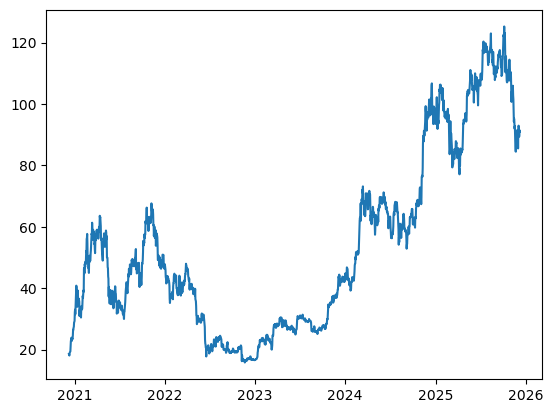

In [39]:
import matplotlib.pyplot as plt
plt.plot(df['Tarih'], df['Deger'])

In [43]:
df.set_index('Tarih').resample('M').mean()[['Deger']]

/var/folders/22/j5k7n31s4p1fkq4x0frr3myc0000gn/T/ipykernel_3403/728245877.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.set_index('Tarih').resample('M').mean()[['Deger']]


,Deger
Tarih,
2020-12-31,23.036739
2021-01-31,34.764710
2021-02-28,46.323179
2021-03-31,54.979387
2021-04-30,57.115300
...,...
2025-08-31,114.802677
2025-09-30,113.091400
2025-10-31,114.097452


In [47]:
df.head(1)

,Tarih,Deger,Yil,Ay,Gun,HaftaninGunu,Dunku_Deger
1,2020-12-09,18.565,2020,12,9,2,18.337


In [49]:
X = df.drop(columns = ['Tarih', 'Deger'])
y = df.Deger

In [51]:
from sklearn.model_selection import train_test_split

In [53]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle= False)

In [55]:
print(f"Eğitim Verisi: {X_train.shape[0]} satır")
print(f"Test Verisi: {X_test.shape[0]} satır")

Eğitim Verisi: 1461 satır
Test Verisi: 366 satır


In [57]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso

In [60]:
model_configs = {
    'LinearRegression': {
        'model': LinearRegression(),
        'params': {} # Linear Regression'da genelde hiperparametre aranmaz
    },
    'Ridge': {
        'model': Ridge(),
        'params': {
            'regressor__alpha': [0.01, 0.1, 1.0, 10.0, 100.0] # Ceza katsayısı
        }
    },
    'Lasso': {
        'model': Lasso(),
        'params': {
            'regressor__alpha': [0.001, 0.01, 0.1, 1.0, 10.0] # Ceza katsayısı
        }
    }
}

In [62]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

In [64]:
tscv = TimeSeriesSplit(n_splits=5)

results = []

print("Modeller eğitiliyor ve GridSearch yapılıyor...\n")

for model_name, config in model_configs.items():
    # Pipeline Kurulumu
    pipe = Pipeline([
        ('scaler', StandardScaler()),     # Veriyi standardize et
        ('regressor', config['model'])    # Modeli koy
    ])
    
    # GridSearch Kurulumu
    grid = GridSearchCV(
        estimator=pipe, 
        param_grid=config['params'], 
        cv=tscv,                          # Zaman serisi uyumlu CV
        scoring='neg_mean_squared_error', # Hata metriği (MSE)
        n_jobs=-1                         # Tüm işlemcileri kullan
    )
    
    # Eğit
    grid.fit(X_train, y_train)
    
    # En iyi modeli al ve test et
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    
    # Metrikleri hesapla
    rmse = np.sqrt(mean_squared_error(y_test, y_pred)) # Root Mean Squared Error
    r2 = r2_score(y_test, y_pred)
    
    print(f"--- {model_name} ---")
    print(f"En İyi Parametreler: {grid.best_params_}")
    print(f"Test Seti RMSE: {rmse:.4f}")
    print(f"Test Seti R2 Score: {r2:.4f}\n")
    
    results.append({
        'Model': model_name,
        'Best_Model_Object': best_model,
        'RMSE': rmse,
        'R2': r2
    })

# Sonuçları karşılaştırma (En düşük RMSE en iyisidir)
results_df = pd.DataFrame(results).sort_values(by='RMSE')
print("KAZANAN MODEL:")
print(results_df.iloc[0])

Modeller eğitiliyor ve GridSearch yapılıyor...

--- LinearRegression ---
En İyi Parametreler: {}
Test Seti RMSE: 2.2661
Test Seti R2 Score: 0.9594

--- Ridge ---
En İyi Parametreler: {'regressor__alpha': 0.01}
Test Seti RMSE: 2.2661
Test Seti R2 Score: 0.9594

--- Lasso ---
En İyi Parametreler: {'regressor__alpha': 0.01}
Test Seti RMSE: 2.2635
Test Seti R2 Score: 0.9595

KAZANAN MODEL:
Model                                                Lasso
Best_Model_Object    (StandardScaler(), Lasso(alpha=0.01))
RMSE                                              2.263453
R2                                                0.959517
Name: 2, dtype: object


In [66]:
final_best_model = results_df.iloc[0]['Best_Model_Object']

In [68]:
import joblib

# Kazanan modeli (final_best_model değişkenindeydi) kaydediyoruz
# Dosya adını projenle uyumlu verebilirsin
filename = 'BIT_Model.pkl'

joblib.dump(final_best_model, filename)

print(f"Model başarıyla '{filename}' olarak kaydedildi!")

Model başarıyla 'BIT_Model.pkl' olarak kaydedildi!


In [70]:
df.to_csv('bitcoin_fit_veri.csv')

In [72]:
import seaborn as sns
import matplotlib.pyplot as plt

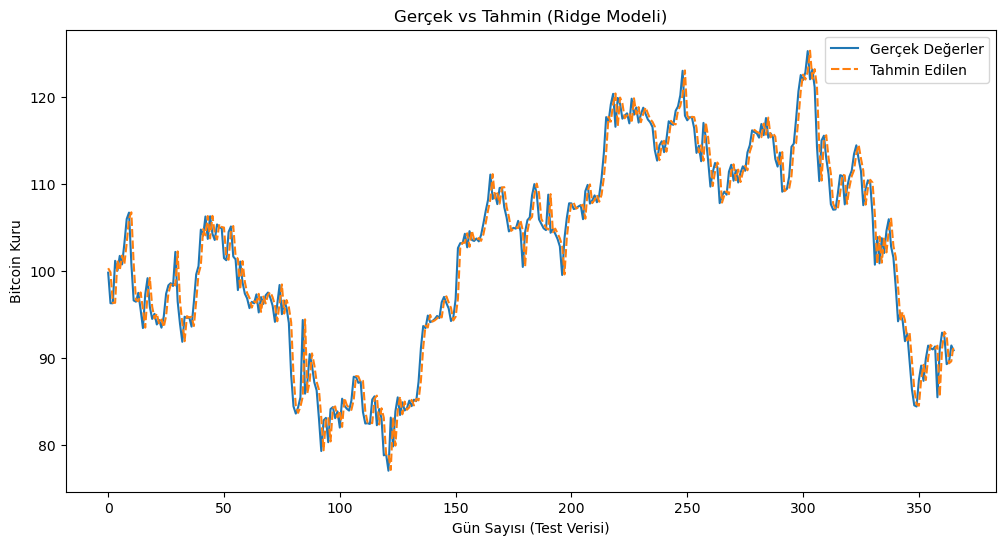

In [74]:
# 1. Tahminleri alalım
tahminler = final_best_model.predict(X_test)

# 2. Karşılaştırma DataFrame'i oluşturalım
# y_test.values diyerek indeksi çöpe atıyoruz, sadece rakamları alıyoruz.
karsilastirma = pd.DataFrame({
    'Gerçek Değerler': y_test.values,
    'Tahmin Edilen': tahminler
})

# 3. Çizdirelim
plt.figure(figsize=(12, 6))
sns.lineplot(data=karsilastirma)
plt.title('Gerçek vs Tahmin (Ridge Modeli)')
plt.ylabel('Bitcoin Kuru')
plt.xlabel('Gün Sayısı (Test Verisi)')
plt.show()